In [1]:
import tenpy
import sys
sys.path.append('..')
from tenpy.networks.mps import TransferMatrix
# import importlib
# # importlib.reload(sys.modules['src'])
# importlib.reload(sys.modules['utils.bosonization'])
# importlib.reload(sys.modules['utils.slurmhelpers'])

from src.extendedHubbard import HubbardSpinDepV, run_idmrg
from utils.bosonization import ret_Vpm_crit, compute_Luttinger_parameter
from utils.slurmhelpers import ret_arr_for_taskid
import src.observables as observables
import utils.io as io
import logging 
logging.basicConfig(level=logging.INFO)
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import re, glob
import pandas as pd
print(f"TeNPy version: {tenpy.__version__}")
DATA_ROOT = '../../data/iDMRG/'


TeNPy version: 1.1.0


In [7]:
REQ_DATA = ['rev/scanChi200',]
PATH_TO_REQ_DATA = [os.path.join(DATA_ROOT, req_data_val) for req_data_val in REQ_DATA]

file_list = [
    os.path.join(req_path, f)
    for req_path in PATH_TO_REQ_DATA
    for f in os.listdir(req_path)
]

tpsi, tparams = io.load_mps_with_metadata(file_list[0])
tparams.keys()

dict_keys(['diagnostics', 'dmrg_params', 'model_params'])

In [8]:
def atomic_action(file): 
    psi, metadata = io.load_mps_with_metadata(file)
    model_params = metadata['model_params']
    row_dict = {
        'psi' : psi, 
        'dV' : model_params['Vpm'] - model_params['Vpp'], 
        'mean_Sz' : np.mean(psi.expectation_value("Sz")), 
        'mean_fill' : np.mean(psi.expectation_value("Ntot")),
        'model_params' : model_params, 
        'diagnostics' : metadata['diagnostics']
    }
    return row_dict
    
df = pd.DataFrame([atomic_action(f) for f in file_list])
df = df.sort_values('dV')
df


,psi,dV,mean_Sz,mean_fill,model_params,diagnostics
28,"MPS, L=4, bc='infinite'.\nchi: [200, 200, 200,...",3.50,1.531576e-08,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.3, 'Vpp': 0.8, 'bc...","{'Delta_E': [nan, -1.8931474187411369e-06, -3...."
24,"MPS, L=4, bc='infinite'.\nchi: [200, 200, 200,...",3.51,4.297534e-09,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.31, 'Vpp': 0.8, 'b...","{'Delta_E': [nan, -1.8518065189709887e-06, -4...."
17,"MPS, L=4, bc='infinite'.\nchi: [200, 200, 200,...",3.52,2.297703e-08,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.32, 'Vpp': 0.8, 'b...","{'Delta_E': [nan, -1.3419943570625036e-06, -4...."
3,"MPS, L=4, bc='infinite'.\nchi: [200, 200, 200,...",3.53,5.007395e-08,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.33, 'Vpp': 0.8, 'b...","{'Delta_E': [nan, -1.4113320503383875e-06, -3...."
9,"MPS, L=4, bc='infinite'.\nchi: [200, 200, 200,...",3.54,-7.716658e-08,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.34, 'Vpp': 0.8, 'b...","{'Delta_E': [nan, -1.567064828122966e-06, -5.9..."
40,"MPS, L=4, bc='infinite'.\nchi: [200, 200, 200,...",3.55,1.954836e-08,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.35, 'Vpp': 0.8, 'b...","{'Delta_E': [nan, -1.2293079635128378e-06, -4...."
18,"MPS, L=4, bc='infinite'.\nchi: [200, 200, 200,...",3.56,1.245432e-02,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.36, 'Vpp': 0.8, 'b...","{'Delta_E': [nan, -1.4551438653143124e-06, -4...."
32,"MPS, L=4, bc='infinite'.\nchi: [200, 200, 200,...",3.57,3.750526e-02,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.37, 'Vpp': 0.8, 'b...","{'Delta_E': [nan, -8.753209840506315e-07, -1.0..."
4,"MPS, L=4, bc='infinite'.\nchi: [200, 200, 200,...",3.58,5.097804e-02,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.38, 'Vpp': 0.8, 'b...","{'Delta_E': [nan, -1.7531947378301993e-06, -5...."
13,"MPS, L=4, bc='infinite'.\nchi: [200, 200, 200,...",3.59,6.102329e-02,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.39, 'Vpp': 0.8, 'b...","{'Delta_E': [nan, -1.3750905054621397e-07, -2...."


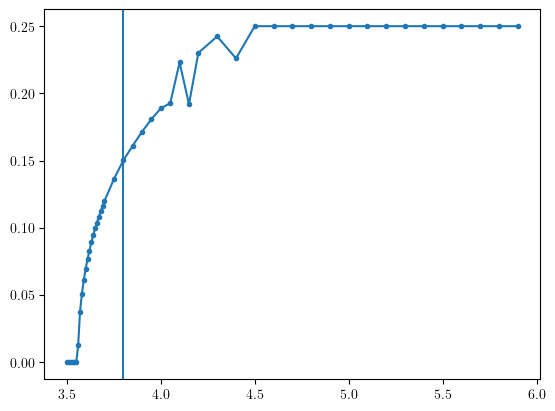

In [42]:
fig, ax = plt.subplots(1)
ax.plot(df['dV'], np.abs(df['mean_Sz']), '.-', c='C0')
# ax.plot(df['dV'], np.abs(df['mean_fill']), '.-', c='C1')
ax.axvline(3.8)

In [12]:
psicrit = df[np.isclose(df['dV'], 3.55)]['psi'].iloc[0]
psifm= df[np.isclose(df['dV'], 3.7)]['psi'].iloc[0]
distrange = 100
fmspincorr = observables.SzSz_corr(psifm, length=distrange, connected=True)
fmchargecorr = observables.charge_corr(psifm, length=distrange, connected=True)
electroncorr = observables.electron_corr(psicrit, length=distrange)
fmelectroncorr = observables.electron_corr(psifm, length=distrange)

In [11]:
xicrit, xifm = psicrit.correlation_length2(), psifm.correlation_length2()
xicrit, xifm

(np.float64(87.79263921064063), np.float64(63.06466851065981))

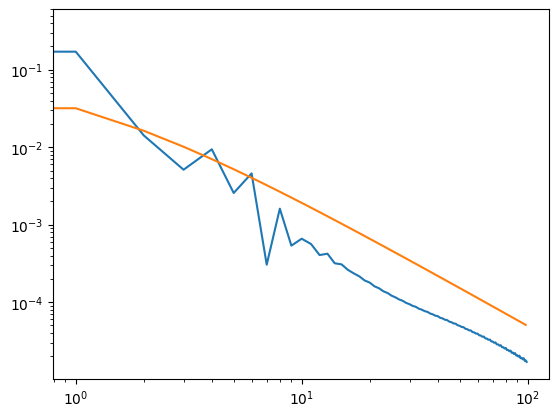

In [13]:
plt.plot(fmchargecorr)
plt.plot(0.1 * (np.arange(distrange, dtype=float)[1:]**(-1.65)))
plt.yscale('log')
plt.xscale('log')

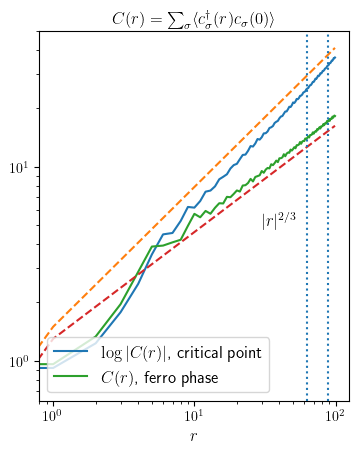

In [23]:
fig, ax = plt.subplots()
fig.set_figwidth(4)
plt.rcParams['text.usetex'] = True
ax.plot(np.abs(np.log(observables.denoise_rolling(np.abs(electroncorr), window=4))), label=r'$\log|C(r)|$, critical point')
# ax.plot(np.abs((observables.denoise_rolling(np.abs(pmelectroncorr), window=4))), label=r'$C(r)$, para phase')

ax.plot(1.5*np.arange(distrange)**(0.72), ls='--')
ax.text(30, 5, r'$|r|^{2/3}$', fontsize=12)
# plt.plot(0.025 * (np.arange(distrange)[1:])**-1.65)


ax.plot(np.abs(np.log(observables.denoise_rolling(np.abs(fmelectroncorr), window=4))), label=r'$C(r)$, ferro phase')
ax.plot(1.3*np.arange(distrange)**(0.55), ls='--')

# ax.plot(1.5*np.arange(distrange)**(1./4.), ls='--')
ax.legend(loc='lower left', fontsize=12)
ax.set_xlabel(r'$r$', fontsize=12)
ax.set_title(r"$C(r) = \sum_{\sigma}\langle c^\dagger_\sigma(r) c_\sigma(0) \rangle$", fontsize=12)

ax.axvline(xicrit ,ls=':')
# ax.axvline(xipm ,ls=':')
ax.axvline(xifm ,ls=':')

ax.set_yscale('log')
ax.set_xscale('log')
# ax.set_xlim(0,200)
# ax.set_ylim(1e-10, 1)
# fig.savefig('showstretchedExp.pdf', bbox_inches='tight')

In [ ]:
# pm_pmcorr = observables.SpSm_corr(psipm, distrange)
crit_pmcorr = observables.SpSm_corr(psicrit, distrange)

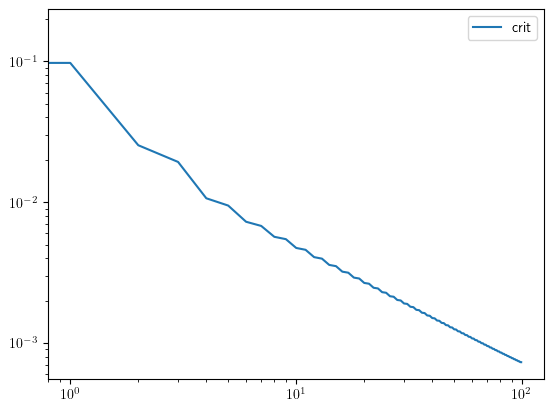

In [87]:
xvals = np.arange(distrange)
# plt.plot(xvals, observables.denoise_rolling(np.abs(pm_pmcorr), window=2), label='para')
plt.plot(xvals, observables.denoise_rolling(np.abs(crit_pmcorr), window=2), label='crit')
# plt.plot(xvals, xvals**)
plt.yscale('log')
plt.xscale('log')
plt.legend()

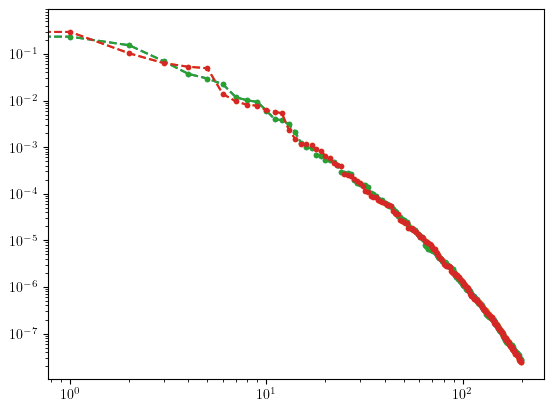

In [27]:
for i in [0,1,2,3]:
    plt.loglog(np.exp(-np.array(psifm.entanglement_spectrum()))[i], ls='--', marker='.')

In [28]:
# evspm,   _ = TransferMatrix(psipm, psipm).eigenvectors(100)
evscrit, _ = TransferMatrix(psicrit, psicrit).eigenvectors(100)
evsfm,   _ = TransferMatrix(psifm, psifm).eigenvectors(100)  

[-4.45395483e-02+0.j -5.84595716e-02+0.j -2.18781921e-02+0.j
 -4.93388373e-02+0.j -4.59781261e-02+0.j -3.17610958e-02+0.j
 -1.46906371e-02+0.j -3.44562746e-03+0.j -5.74921504e-02+0.j
 -1.46507876e-02+0.j -3.49231051e-02+0.j -2.81687558e-02+0.j
 -3.42032681e-02+0.j -2.72243579e-05+0.j -7.12898447e-03+0.j
 -1.46568310e-02+0.j -3.01006165e-03+0.j -1.84963058e-02+0.j
 -2.24146467e-02+0.j -1.97834243e-02+0.j]


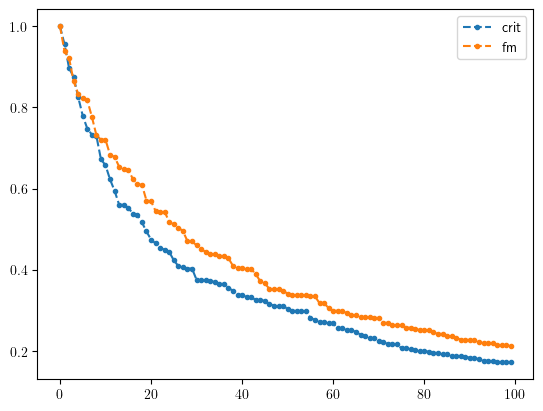

In [30]:
# plt.plot(np.arange(100), np.abs(evspm), ls='--', marker='.', label='pm')
plt.plot(np.arange(100), np.abs(evscrit), ls='--', marker='.', label='crit')
plt.plot(np.arange(100), np.abs(evsfm), ls='--', marker='.', label='fm')
plt.legend()
print(np.diff(evscrit)[0:20])

In [31]:
import numpy as np

def op_correlation_idmrg(psi, opA=("Sp", "Sp"), opAdag=("Sm", "Sm"),
                          i0=0, xs=None, autoJW=True, connected=False):
    """
    <O(x) O_dag(i0)> for an infinite MPS from iDMRG, where
        O(n)     = op(opA[0],    n) * op(opA[1],    n+1)
        O_dag(n) = op(opAdag[0], n+1) * op(opAdag[1], n)

    Default: O(n) = S+_n S+_{n+1}, O_dag(n) = S-_{n+1} S-_n
    -- matches your HubbardSpinDepV model (SpinHalfFermionSite, cons_Sz="None").

    Built entirely from psi.expectation_value_term, which evaluates a product
    of single-site operators directly against the MPS canonical-form tensors.
    This is the robust choice for infinite MPS: TeNPy explicitly warns that
    apply()/overlap()-based tricks for iMPS do NOT give correct expectation
    values (they break translation invariance under the hood), so we avoid
    that route entirely here.

    Parameters
    ----------
    psi     : tenpy.networks.mps.MPS   (infinite MPS, e.g. from run_idmrg())
    opA     : tuple(str,str)  operator names for O(n)
    opAdag  : tuple(str,str)  operator names for O_dag(n)
    i0      : int   site where O_dag is anchored
    xs      : None or iterable of int  separations (O's left operator sits at i0+x)
              Default: 1 .. 10*L (L = unit cell length)
    autoJW  : bool  let TeNPy insert Jordan-Wigner strings automatically
              (harmless here since Sp/Sm are built from an even number of
              fermionic operators on each site, i.e. bosonic operators)
    connected : bool  if True, subtract <O><O_dag> (each evaluated with the
              same expectation_value_term machinery) to get the connected part

    Returns
    -------
    xs   : ndarray[int]
    corr : ndarray[complex]   <psi| O(i0+x) O_dag(i0) |psi>
    """
    L = psi.L
    if xs is None:
        xs = np.arange(1, 10 * L)
    xs = np.asarray(xs)

    term_Odag = [(opAdag[0], i0 + 1), (opAdag[1], i0)]   # O_dag(i0)

    corr = np.zeros(len(xs), dtype=complex)
    for k, x in enumerate(xs):
        term_O = [(opA[0], i0 + x), (opA[1], i0 + x + 1)]   # O(i0+x)
        term = term_O + term_Odag                            # product, left-to-right = operator order
        val = psi.expectation_value_term(term, autoJW=autoJW)
        corr[k] = val

    if connected:
        O_val = psi.expectation_value_term([(opA[0], i0), (opA[1], i0 + 1)], autoJW=autoJW)
        Odag_val = psi.expectation_value_term(term_Odag, autoJW=autoJW)
        corr = corr - O_val * Odag_val

    return xs, corr

In [36]:
psi_deepfm = df[np.isclose(df['dV'], 5.0)]['psi'].iloc[0]
xs, corr4ptdeepfm = op_correlation_idmrg(psi_deepfm, i0=0, xs=np.arange(1,100))

In [32]:
# xs, corr4ptpm =   op_correlation_idmrg(psipm, i0=0, xs=np.arange(1,100))
xs, corr4ptcrit = op_correlation_idmrg(psicrit, i0=0, xs=np.arange(1,100))
_, corr4ptfm = op_correlation_idmrg(psifm, i0=0, xs=np.arange(1,100))

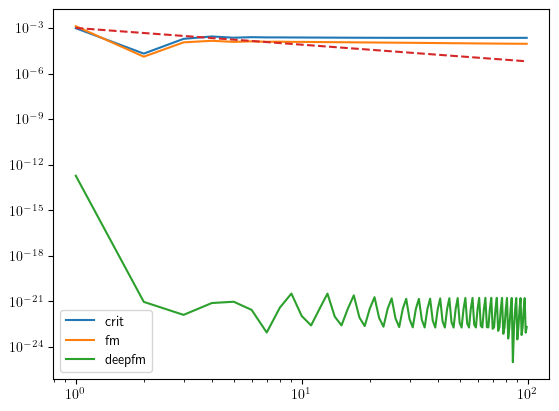

In [39]:
# plt.plot(xs, corr4ptpm.real, label='pm')
plt.plot(xs, corr4ptcrit.real, label='crit')
plt.plot(xs, corr4ptfm.real, label='fm')
plt.plot(xs, np.abs(corr4ptdeepfm), label='deepfm')
plt.plot(xs, 0.001 * xs**(-1.1),ls='--') # makes sense if the scaling is x^{-4/Ks}
plt.yscale('log')
plt.xscale('log')
plt.legend()